In [1]:
import numpy as np
import time

import matplotlib.pyplot as plt
import os

from sirf.Gadgetron import CoilSensitivityData
from sirf.Gadgetron import preprocess_acquisition_data
from sirf.Gadgetron import AcquisitionData

In [2]:
def manual_fft( k_array ):
    image_array = np.zeros(k_array.shape, np.complex64)
    for sl in range(image_array.shape[0]):
        for c in range(image_array.shape[2]):
            image_array[sl,:,c,:] = np.fft.fftshift( np.fft.ifft2( np.fft.ifftshift(k_array[sl, :,c,:])))
    image_array = np.sqrt(np.sum(np.square(np.abs(image_array)),2))

    return image_array
     


In [3]:
fname = 'work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5'
#fname = 'work/data/h5/1meas_MID00614_FID129152_CONVENTIONAL_RECON_SEQD_GF2_AX_RL_mod.h5'

In [4]:
acq_data = AcquisitionData(fname)
acq_data = preprocess_acquisition_data(acq_data)

csm = CoilSensitivityData()
csm.smoothness = 100
csm.calculate(acq_data)
csm_array = csm.as_array()
print(csm_array.shape)

reading from work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5
0%..10%..20%..30%..40%..50%..60%..70%..80%..90%..100%..
Finished reading acquisitions from work/data/h5/1meas_MID00619_FID129157_AI_RECON_SEQD_512_GF4_AX_RL_mod.h5
ignoring acquisition 0
Message received with ID: 5
Input stream has terminated
(18, 18, 512, 512)


In [5]:
# Save k-space data
pe_index = acq_data.get_ISMRMRD_info('kspace_encode_step_1')
slice_index = acq_data.get_ISMRMRD_info('slice')

In [6]:
k_list = acq_data.as_array()
k_array = np.zeros((18, 512, 18, 512), dtype=np.complex64)
for idx in range(k_list.shape[0]):
    if pe_index[idx] < 512:
        k_array[slice_index[idx], pe_index[idx],:,:] = k_list[idx,:,:]

np.savez(fname.replace('.h5', '.npz'), kraw=k_array, csm=csm_array, allow_pickle=True)

Text(0.5, 1.0, 'Reconstructed image data (magnitude)')

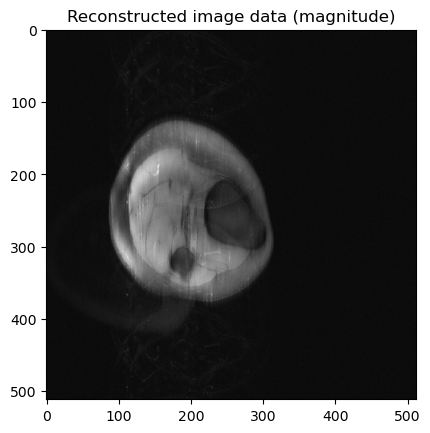

In [7]:
im = manual_fft(k_array)
image_array = abs(im)
image_array = image_array/image_array.max()

plt.figure(1)
plt.set_cmap('gray')
plt.imshow(image_array[0,:,:], vmin=0, vmax=0.7)
plt.title('Reconstructed image data (magnitude)') 